# NOTEBOOK 08 - EVALUACIÓN mAP (V2, V3, V4)

## Propósito
Evaluar y comparar los modelos V2, V3 y V4 sobre un dataset de test puro (hold-out).

## Modelos:
- **V2**: 500 imgs, GT ruidoso, augmentation básico
- **V3**: 600 imgs, GT ruidoso, augmentation completo
- **V4**: ~10k imgs, GT ruidoso, augmentation completo
- **V5** (futuro): ~615 imgs, GT limpio

## PASO 1: Generar Test Set Puro (sin contaminación de train)

In [1]:
import os
import shutil
import random
import pandas as pd
from tqdm import tqdm

def generar_test_set_reserva(
    csv_path, golden_dir,
    dirs_to_blacklist_extra,   # carpetas de entrenamiento de V2/V3/V4 (NO el Golden)
    output_dir,
    gt_prefix="gt_", seed=999
):
    """
    Test set con ETIQUETAS LIMPIAS usando las imágenes de Reserva
    (Asignacion == 'Reserva'), excluyendo cualquiera vista en el train de V2/V3/V4.
    Las de V5_train ya quedan afuera porque filtramos por Asignacion en el CSV.
    """
    print("--- TEST SET LIMPIO (RESERVA, HOLD-OUT REAL) ---")

    df = pd.read_csv(csv_path)

    # Candidatas: Reserva corregida (GT limpio, fuera del train de V5)
    reserva = df.loc[
        (df["Asignacion"] == "Reserva") & (df["Estado"] == "DONE"),
        "ID_Imagen"
    ].astype(str).tolist()
    print(f"Reserva (GT limpio, fuera de V5_train): {len(reserva)}")

    # Blacklist = tiles vistos por V2/V3/V4
    blacklist = set()
    for d in dirs_to_blacklist_extra:
        if not os.path.exists(d):
            print(f"[WARN] No existe (se ignora): {d}")
            continue
        for root, _, files in os.walk(d):
            for f in files:
                if f.endswith(".tif"):
                    blacklist.add(f)
    print(f"Imágenes vistas por V2/V3/V4: {len(blacklist)}")

    # Test = Reserva que NINGÚN modelo vio en entrenamiento
    test_tiles = [t for t in reserva if t not in blacklist]
    print(f">>> Test candidatas (Reserva no vista por ningún modelo): {len(test_tiles)}")

    if len(test_tiles) == 0:
        print("[!] No quedaron candidatas: toda la Reserva fue usada en train de V2/V3/V4.")
        print("    -> Conviene ir directo al test set 2026.")
        return

    # Copiar tile + gt_ shapefile (LIMPIO) desde el Golden
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir)

    golden_files = os.listdir(golden_dir)
    copiadas, sin_gt = 0, []
    for tif in tqdm(test_tiles, desc="Copiando test set"):
        src_tif = os.path.join(golden_dir, tif)
        if not os.path.exists(src_tif):
            continue
        shutil.copy2(src_tif, os.path.join(output_dir, tif))
        base = os.path.splitext(tif)[0]
        gt_base = gt_prefix + base
        gt_shp = next((f for f in golden_files if f.startswith(gt_base) and f.endswith(".shp")), None)
        if gt_shp is None:
            sin_gt.append(tif)   # tile sin silos -> negativo (se copia igual)
            copiadas += 1
            continue
        shp_base = os.path.splitext(gt_shp)[0]
        for f in golden_files:
            if f.startswith(shp_base):
                shutil.copy2(os.path.join(golden_dir, f), os.path.join(output_dir, f))
        copiadas += 1

    print(f"\nTest set listo: {copiadas} imágenes con GT limpio en {output_dir}")
    if sin_gt:
        print(f"[NOTA] {len(sin_gt)} sin gt_ shapefile (probables 'sin silos'): incluidas como negativos.")


# --- EJECUTAR ---
generar_test_set_reserva(
    csv_path=r"D:\Silos\seguimiento_gt_v5_final.csv",
    golden_dir=r"D:\Silos\Golden_Dataset_1000",
    dirs_to_blacklist_extra=[
        r"D:\Silos\Dataset_V2",
        r"D:\Silos\Dataset_V3",
        r"D:\Silos\Dataset_V4_10k",
    ],
    output_dir=r"D:\Silos\Dataset_Test_Reserva",
    gt_prefix="gt_",
    seed=999
)

--- TEST SET LIMPIO (RESERVA, HOLD-OUT REAL) ---
Reserva (GT limpio, fuera de V5_train): 54
Imágenes vistas por V2/V3/V4: 10644
>>> Test candidatas (Reserva no vista por ningún modelo): 27


Copiando test set: 100%|██████████| 27/27 [02:28<00:00,  5.52s/it]


Test set listo: 27 imágenes con GT limpio en D:\Silos\Dataset_Test_Reserva


## PASO 2: Evaluación comparativa V2 vs V3 vs V4

In [2]:
## PASO 2: Evaluación comparativa V2 vs V3 vs V4 vs V5 (con dedup)
import os
import torch
import torchvision
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import ResNet50_Weights
from torchvision.ops import box_iou, nms as tv_nms
from tqdm import tqdm

# --- CONFIGURACIÓN ---
MODELS = {
    'V2': r"D:\Silos\modelo_silos_v2_optimizado.pth",
    'V3': r"D:\Silos\modelo_silos_v3_aug.pth",
    'V4': r"D:\Silos\modelo_silos_v4_10k.pth",
    'V5': r"D:\Silos\modelo_silos_v5_FINAL.pth",
}

TEST_DIR = r"D:\Silos\Dataset_Test_Reserva"
THRESHOLD = 0.5
IOU_THRESHOLD = 0.15
NMS_IOU = 0.3            # deduplicación post-hoc (igual para todos los modelos)


def get_model_architecture(num_classes=2):
    anchor_sizes = ((16,), (32,), (64,), (128,), (256,))
    aspect_ratios = ((0.2, 0.5, 1.0, 2.0, 5.0),) * len(anchor_sizes)
    anchor_generator = AnchorGenerator(sizes=anchor_sizes, aspect_ratios=aspect_ratios)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights=None,
        weights_backbone=ResNet50_Weights.DEFAULT,
        rpn_anchor_generator=anchor_generator
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def preprocess_image(img_path):
    with rasterio.open(img_path) as src:
        try:
            img_data = src.read([1, 2, 3])
        except:
            img_data = src.read()[:3, :, :]
    img_data = np.nan_to_num(img_data.astype(np.float32), nan=0.0)
    max_val = np.max(img_data)
    if max_val > 255.0:
        img_data /= 10000.0
    elif max_val > 1.0:
        img_data /= 255.0
    img_data = np.clip(img_data, 0, 1)
    return torch.as_tensor(img_data, dtype=torch.float32)


def get_gt_boxes(img_name, test_dir):
    """Bounding boxes del Ground Truth (gt_<base>.shp)."""
    base_name = os.path.splitext(img_name)[0]
    img_path = os.path.join(test_dir, img_name)
    files_in_dir = os.listdir(test_dir)
    shp_name = next(
        (f for f in files_in_dir if f.startswith("gt_" + base_name) and f.endswith('.shp')),
        None
    )
    if not shp_name:
        return torch.zeros((0, 4), dtype=torch.float32)
    shp_path = os.path.join(test_dir, shp_name)
    with rasterio.open(img_path) as src:
        transform = src.transform
        height = src.height
        width = src.width
    boxes = []
    try:
        gdf = gpd.read_file(shp_path)
        if not gdf.empty:
            for geom in gdf.geometry:
                if geom is None:
                    continue
                if geom.geom_type == 'Polygon':
                    polys = [geom]
                elif geom.geom_type == 'MultiPolygon':
                    polys = list(geom.geoms)
                else:
                    polys = []
                for p in polys:
                    xs, ys = zip(*p.exterior.coords)
                    rows, cols = rasterio.transform.rowcol(transform, xs, ys)
                    y_min = max(0, min(rows))
                    y_max = min(height, max(rows))
                    x_min = max(0, min(cols))
                    x_max = min(width, max(cols))
                    if x_max > x_min + 1 and y_max > y_min + 1:
                        boxes.append([x_min, y_min, x_max, y_max])
    except Exception:
        pass
    if len(boxes) == 0:
        return torch.zeros((0, 4), dtype=torch.float32)
    return torch.as_tensor(boxes, dtype=torch.float32)


def evaluate_model(model_path, model_name, device):
    """Evalúa un modelo y retorna métricas (con dedup NMS)."""
    print(f"\n{'='*50}")
    print(f"  Evaluando: {model_name}")
    print(f"{'='*50}")
    if not os.path.exists(model_path):
        print(f"ERROR: No existe {model_path}")
        return None
    model = get_model_architecture()
    try:
        sd = torch.load(model_path, map_location=device)
        if isinstance(sd, dict) and 'model' in sd and 'optimizer' in sd:
            sd = sd['model']                      # extraer pesos si es checkpoint
        model.load_state_dict(sd)
    except Exception as e:
        print(f"Error cargando modelo: {e}")
        return None
    model.to(device)
    model.eval()

    val_images = [f for f in os.listdir(TEST_DIR) if f.endswith('.tif')]
    if not val_images:
        print("Error: Carpeta de Test vacía.")
        return None

    true_positives = 0
    false_positives = 0
    false_negatives = 0
    total_gt_boxes = 0
    total_pred_boxes = 0
    all_scores = []
    all_matches = []

    for img_name in tqdm(val_images, desc=f"Evaluando {model_name}"):
        img_path = os.path.join(TEST_DIR, img_name)
        gt_boxes = get_gt_boxes(img_name, TEST_DIR)
        total_gt_boxes += len(gt_boxes)

        img_tensor = preprocess_image(img_path)
        with torch.no_grad():
            prediction = model([img_tensor.to(device)])

        pred_boxes = prediction[0]['boxes'].cpu()
        pred_scores = prediction[0]['scores'].cpu()
        mask = pred_scores >= THRESHOLD
        pred_boxes = pred_boxes[mask]
        pred_scores = pred_scores[mask]
        if len(pred_boxes) > 0:                    # <-- DEDUP (NMS)
            keep = tv_nms(pred_boxes, pred_scores, NMS_IOU)
            pred_boxes = pred_boxes[keep]
            pred_scores = pred_scores[keep]
        pred_scores = pred_scores.numpy()
        total_pred_boxes += len(pred_boxes)

        if len(gt_boxes) == 0 and len(pred_boxes) == 0:
            continue
        if len(gt_boxes) == 0:
            false_positives += len(pred_boxes)
            for s in pred_scores:
                all_scores.append(s)
                all_matches.append(0)
            continue
        if len(pred_boxes) == 0:
            false_negatives += len(gt_boxes)
            continue

        iou_matrix = box_iou(pred_boxes, gt_boxes)
        gt_matched = set()
        sorted_indices = np.argsort(-pred_scores)
        for pred_idx in sorted_indices:
            score = pred_scores[pred_idx]
            all_scores.append(score)
            best_iou = 0
            best_gt = -1
            for gt_idx in range(len(gt_boxes)):
                if gt_idx in gt_matched:
                    continue
                iou_val = iou_matrix[pred_idx, gt_idx].item()
                if iou_val > best_iou:
                    best_iou = iou_val
                    best_gt = gt_idx
            if best_iou >= IOU_THRESHOLD and best_gt >= 0:
                true_positives += 1
                gt_matched.add(best_gt)
                all_matches.append(1)
            else:
                false_positives += 1
                all_matches.append(0)
        false_negatives += len(gt_boxes) - len(gt_matched)

    precision = true_positives / max(true_positives + false_positives, 1)
    recall = true_positives / max(true_positives + false_negatives, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-6)

    if len(all_scores) > 0:
        sorted_idx = np.argsort(-np.array(all_scores))
        sorted_matches = np.array(all_matches)[sorted_idx]
        cum_tp = np.cumsum(sorted_matches)
        cum_fp = np.cumsum(1 - sorted_matches)
        precisions = cum_tp / (cum_tp + cum_fp)
        recalls = cum_tp / max(total_gt_boxes, 1)
        ap = 0.0
        for t in np.arange(0, 1.1, 0.1):
            prec_at_recall = precisions[recalls >= t]
            if len(prec_at_recall) > 0:
                ap += np.max(prec_at_recall)
        ap /= 11.0
    else:
        ap = 0.0

    results = {
        'Modelo': model_name,
        'TP': true_positives,
        'FP': false_positives,
        'FN': false_negatives,
        'GT_Total': total_gt_boxes,
        'Pred_Total': total_pred_boxes,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1': round(f1, 4),
        'AP@0.15': round(ap, 4)
    }
    print(f"\nResultados {model_name}:")
    for k, v in results.items():
        print(f"  {k}: {v}")
    return results


# --- EJECUTAR EVALUACIÓN ---
device = torch.device('cpu')
all_results = []
for name, path in MODELS.items():
    result = evaluate_model(path, name, device)
    if result:
        all_results.append(result)

if all_results:
    df = pd.DataFrame(all_results)
    print("\n" + "=" * 70)
    print(f"  TABLA COMPARATIVA (con dedup NMS={NMS_IOU})")
    print("=" * 70)
    print(df.to_string(index=False))
    csv_path = r"D:\Silos\resultados_comparativa.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nResultados guardados en: {csv_path}")


  Evaluando: V2


Evaluando V2: 100%|██████████| 27/27 [04:34<00:00, 10.16s/it]



Resultados V2:
  Modelo: V2
  TP: 484
  FP: 227
  FN: 102
  GT_Total: 586
  Pred_Total: 711
  Precision: 0.6807
  Recall: 0.8259
  F1: 0.7463
  AP@0.15: 0.7835

  Evaluando: V3


Evaluando V3: 100%|██████████| 27/27 [02:20<00:00,  5.22s/it]



Resultados V3:
  Modelo: V3
  TP: 440
  FP: 110
  FN: 146
  GT_Total: 586
  Pred_Total: 550
  Precision: 0.8
  Recall: 0.7509
  F1: 0.7746
  AP@0.15: 0.7024

  Evaluando: V4


Evaluando V4: 100%|██████████| 27/27 [02:34<00:00,  5.73s/it]



Resultados V4:
  Modelo: V4
  TP: 484
  FP: 181
  FN: 102
  GT_Total: 586
  Pred_Total: 665
  Precision: 0.7278
  Recall: 0.8259
  F1: 0.7738
  AP@0.15: 0.7806

  Evaluando: V5


Evaluando V5: 100%|██████████| 27/27 [02:37<00:00,  5.85s/it]


Resultados V5:
  Modelo: V5
  TP: 484
  FP: 76
  FN: 102
  GT_Total: 586
  Pred_Total: 560
  Precision: 0.8643
  Recall: 0.8259
  F1: 0.8447
  AP@0.15: 0.7954

  TABLA COMPARATIVA (con dedup NMS=0.3)
Modelo  TP  FP  FN  GT_Total  Pred_Total  Precision  Recall     F1  AP@0.15
    V2 484 227 102       586         711     0.6807  0.8259 0.7463   0.7835
    V3 440 110 146       586         550     0.8000  0.7509 0.7746   0.7024
    V4 484 181 102       586         665     0.7278  0.8259 0.7738   0.7806
    V5 484  76 102       586         560     0.8643  0.8259 0.8447   0.7954

Resultados guardados en: D:\Silos\resultados_comparativa.csv


In [3]:
# === Imagen más representativa + GT coloreado por estado de detección (para QGIS) ===
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon
from pathlib import Path

ag = ['V2', 'V4', 'V5']
if 'loaded' not in globals() or not all(m in loaded for m in ag):
    loaded = {}
    for n, p in MODELS.items():
        if not os.path.exists(p): continue
        mm = get_model_architecture().to(device); sd = torch.load(p, map_location=device)
        if isinstance(sd, dict) and 'model' in sd and 'optimizer' in sd: sd = sd['model']
        mm.load_state_dict(sd); mm.eval(); loaded[n] = mm

def dedup_boxes(model, img_t):
    with torch.no_grad():
        pr = model([img_t.to(device)])
    b = pr[0]['boxes'].cpu(); s = pr[0]['scores'].cpu()
    mk = s >= THRESHOLD; b, s = b[mk], s[mk]
    if len(b) > 0:
        keep = tv_nms(b, s, NMS_IOU); b, s = b[keep], s[keep]
    return b, s.numpy()

def matched_idx(pred_boxes, scores, gt):
    matched = set()
    if len(gt) > 0 and len(pred_boxes) > 0:
        iou = box_iou(pred_boxes, gt)
        for pi in np.argsort(-scores):
            best, bg = 0, -1
            for gj in range(len(gt)):
                if gj in matched: continue
                v = iou[pi, gj].item()
                if v > best: best, bg = v, gj
            if best >= IOU_THRESHOLD and bg >= 0:
                matched.add(bg)
    return matched

test_imgs = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.tif')])
stats = []
for img_name in test_imgs:
    gt = get_gt_boxes(img_name, TEST_DIR)
    if len(gt) < 5:                                    # imágenes con muy pocos silos no ilustran
        continue
    img_t = preprocess_image(os.path.join(TEST_DIR, img_name))
    with rasterio.open(os.path.join(TEST_DIR, img_name)) as src:
        px = abs(src.transform.a)                      # metros por píxel (~10)
    preds = {m: dedup_boxes(loaded[m], img_t) for m in ag}
    matched_by = {m: matched_idx(preds[m][0], preds[m][1], gt) for m in ag}
    fp = {m: len(preds[m][0]) - len(matched_by[m]) for m in ag}
    n_det = np.array([sum(gi in matched_by[m] for m in ag) for gi in range(len(gt))])
    long_px = np.array([max(g[2]-g[0], g[3]-g[1]) for g in gt.numpy()])
    missed_all = int((n_det == 0).sum())
    det_all = int((n_det == len(ag)).sum())
    gap_px = float(np.median(long_px[n_det==len(ag)]) - np.median(long_px[n_det==0])) if (missed_all>0 and det_all>0) else 0.0
    fp_spread = max(fp.values()) - fp['V5']
    score = 4*min(missed_all,8) + 3*max(fp_spread,0) + min(det_all,20) + max(gap_px,0)
    stats.append(dict(img=img_name, n_gt=len(gt), det_all=det_all, missed_all=missed_all,
                      gap_m=round(gap_px*px,1), FP_V5=fp['V5'], FP_V4=fp['V4'], FP_V2=fp['V2'],
                      score=round(float(score),1)))

stats.sort(key=lambda d: -d['score'])
print("TOP 5 imágenes más representativas:\n")
for d in stats[:5]:
    print(f"  {d['img']}")
    print(f"     silos={d['n_gt']} | los detectan los 3={d['det_all']} | "
          f"no los detecta NADIE={d['missed_all']} (los chicos) | brecha tamaño detect-vs-perdido={d['gap_m']} m")
    print(f"     falsos positivos:  V5={d['FP_V5']}   V4={d['FP_V4']}   V2={d['FP_V2']}   (V5 ensucia menos)\n")

best = stats[0]['img']
base = os.path.splitext(best)[0]
print(f">>> Imagen elegida: {best}\n")

# Exportar el GT del tile elegido con campo 'estado' para colorear en QGIS
gt = get_gt_boxes(best, TEST_DIR)
img_path = os.path.join(TEST_DIR, best)
with rasterio.open(img_path) as src:
    transform, crs, px = src.transform, src.crs, abs(src.transform.a)
img_t = preprocess_image(img_path)
preds = {m: dedup_boxes(loaded[m], img_t) for m in ag}
matched_by = {m: matched_idx(preds[m][0], preds[m][1], gt) for m in ag}
records = []
for gi in range(len(gt)):
    g = gt[gi].numpy(); x1, y1, x2, y2 = g
    nd = sum(gi in matched_by[m] for m in ag)
    estado = "todos" if nd == len(ag) else ("nadie" if nd == 0 else "algunos")
    corners_px = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
    corners_geo = [rasterio.transform.xy(transform, int(round(yp)), int(round(xp))) for xp, yp in corners_px]
    records.append({'estado': estado, 'n_modelos': int(nd),
                    'largo_m': round(max(x2-x1, y2-y1)*px, 1), 'geometry': Polygon(corners_geo)})
out = Path(r"D:\Silos\Pred_Test_Compare") / f"{base}_gt_estado.shp"
gpd.GeoDataFrame(records, geometry='geometry', crs=crs).to_file(out)
print(f"GT con estado exportado: {out}")
print(f"Imagen para el fondo:    {img_path}")
print("\nEn QGIS:")
print("  1) Cargá el .tif de fondo (realce Media ± 2 desv.)")
print("  2) Cargá *_gt_estado.shp y coloreá por el campo 'estado':")
print("       nadie  = rojo   (silos que NINGÚN modelo detecta -> los chicos, el techo)")
print("       algunos= amarillo (borderline)")
print("       todos  = verde  (los fáciles)")
print(f"  3) Cargá {base}_pred_V5.shp y {base}_pred_V2.shp y compar! V2 va a tener muchas más cajas basura.")

TOP 5 imágenes más representativas:

  2020_8_12_1_tile_r05_c04.tif
     silos=7 | los detectan los 3=5 | no los detecta NADIE=1 (los chicos) | brecha tamaño detect-vs-perdido=70.0 m
     falsos positivos:  V5=2   V4=1   V2=34   (V5 ensucia menos)

  2020_6_30_0_tile_r05_c05.tif
     silos=17 | los detectan los 3=8 | no los detecta NADIE=2 (los chicos) | brecha tamaño detect-vs-perdido=-60.0 m
     falsos positivos:  V5=9   V4=39   V2=10   (V5 ensucia menos)

  2020_6_10_0_tile_r14_c08.tif
     silos=46 | los detectan los 3=30 | no los detecta NADIE=9 (los chicos) | brecha tamaño detect-vs-perdido=25.0 m
     falsos positivos:  V5=4   V4=6   V2=7   (V5 ensucia menos)

  2020_7_8_1_tile_r05_c06.tif
     silos=32 | los detectan los 3=13 | no los detecta NADIE=13 (los chicos) | brecha tamaño detect-vs-perdido=0.0 m
     falsos positivos:  V5=2   V4=3   V2=6   (V5 ensucia menos)

  2020_8_12_1_tile_r11_c06.tif
     silos=13 | los detectan los 3=12 | no los detecta NADIE=1 (los chicos) | br

In [8]:
# === Confirmar números de 4.2 y 4.3 (reusa loaded, MODELS, TEST_DIR y tus funciones) ===
import numpy as np
ag = ['V2','V4','V5']; THR = THRESHOLD
test_imgs = sorted(f for f in os.listdir(TEST_DIR) if f.endswith('.tif'))

cache = {}
for im in test_imgs:
    img_t = preprocess_image(os.path.join(TEST_DIR, im))
    d = {'gt': get_gt_boxes(im, TEST_DIR)}
    for m in ag:
        with torch.no_grad(): pr = loaded[m]([img_t.to(device)])
        d[m] = (pr[0]['boxes'].cpu(), pr[0]['scores'].cpu())
    cache[im] = d

def tp_fp(boxes, scores, gt, thr, nms):
    mk = scores >= thr; b, s = boxes[mk], scores[mk]
    if nms and len(b) > 0:
        k = tv_nms(b, s, NMS_IOU); b, s = b[k], s[k]
    mt = matched_idx(b, s.numpy(), gt)
    return len(mt), len(b) - len(mt)

print("modelo | FP sin NMS | FP con NMS | TP")          # -> 230/249 ; 76/181/227
for m in ag:
    fr = sum(tp_fp(*cache[im][m], cache[im]['gt'], THR, False)[1] for im in test_imgs)
    fn, tp = (sum(tp_fp(*cache[im][m], cache[im]['gt'], THR, True)[j] for im in test_imgs) for j in (1,0))
    print(f"  {m}   |   {fr}   |   {fn}   |  {tp}")

dc, sz = [], []                                          # -> 439 / 61 / 86 + tamaños
for im in test_imgs:
    gt = cache[im]['gt']; mtch = {}
    for m in ag:
        b, s = cache[im][m]; mk = s >= THR; b, s = b[mk], s[mk]
        if len(b) > 0: k = tv_nms(b, s, NMS_IOU); b, s = b[k], s[k]
        mtch[m] = matched_idx(b, s.numpy(), gt)
    for gi in range(len(gt)):
        dc.append(sum(gi in mtch[m] for m in ag))
        g = gt[gi].numpy(); sz.append(max(g[2]-g[0], g[3]-g[1]))
dc, sz = np.array(dc), np.array(sz)
print(f"\nGT={len(dc)} | por los 3={(dc==3).sum()} | por ninguna={(dc==0).sum()} | frontera={((dc>0)&(dc<3)).sum()}")
print(f"tamaño px (lado mayor): no detect={np.median(sz[dc==0]):.1f} | detect x3={np.median(sz[dc==3]):.1f}")

print("\nTP por umbral:")                                # -> 497/502/501 ...
for thr in (0.40,0.45,0.50,0.55,0.60):
    print(f"  {thr}: " + " / ".join(str(sum(tp_fp(*cache[im][m], cache[im]['gt'], thr, True)[0] for im in test_imgs)) for m in ag))

modelo | FP sin NMS | FP con NMS | TP
  V2   |   358   |   227   |  484
  V4   |   249   |   181   |  484
  V5   |   230   |   76   |  484

GT=586 | por los 3=439 | por ninguna=61 | frontera=86
tamaño px (lado mayor): no detect=6.0 | detect x3=8.0

TP por umbral:
  0.4: 497 / 502 / 501
  0.45: 491 / 491 / 492
  0.5: 484 / 484 / 484
  0.55: 476 / 469 / 471
  0.6: 459 / 453 / 464


Figura guardada: D:\Silos\analisis_umbral_PR.png


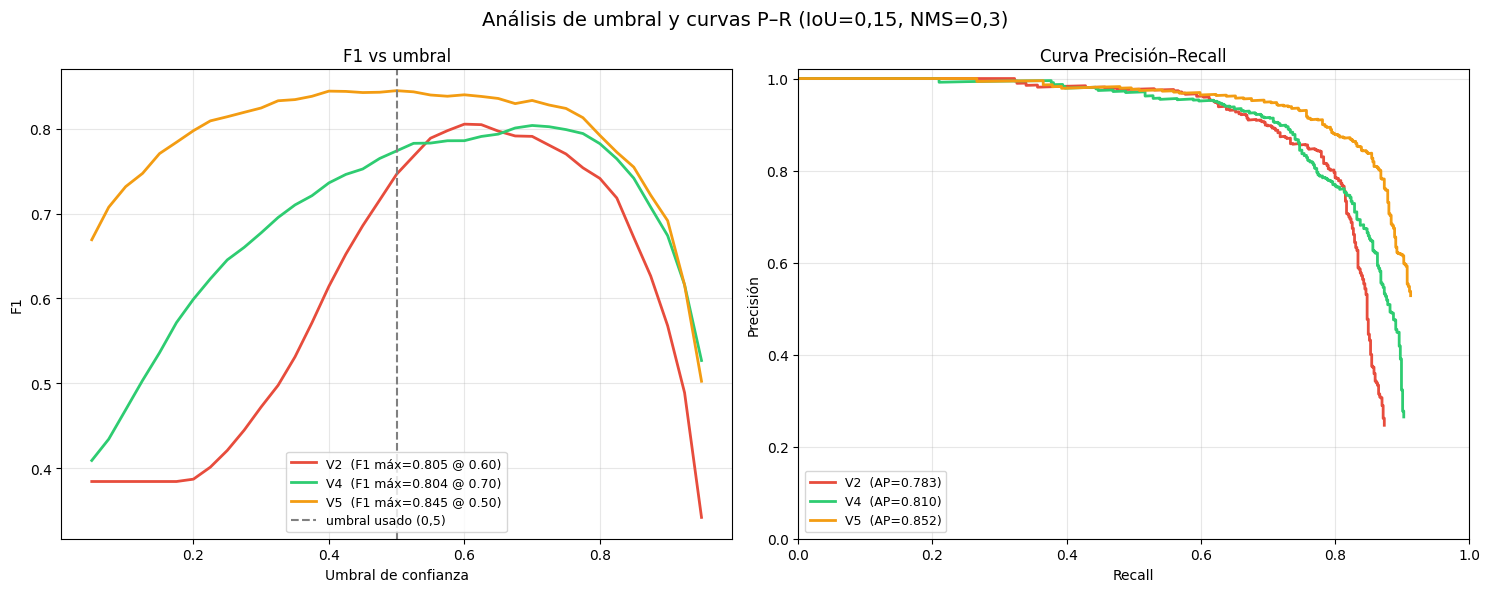


Mejor umbral por F1 (sobre este test — referencial, no para reportar):
  V2: thr* = 0.60
  V4: thr* = 0.70
  V5: thr* = 0.50


In [4]:
# === Curva F1 vs umbral (mejor corte) + curva Precisión-Recall (AP) — figuras tesis ===
import numpy as np
import matplotlib.pyplot as plt

ag = ['V2', 'V4', 'V5']
if 'loaded' not in globals() or not all(m in loaded for m in ag):
    loaded = {}
    for n, p in MODELS.items():
        if not os.path.exists(p): continue
        mm = get_model_architecture().to(device); sd = torch.load(p, map_location=device)
        if isinstance(sd, dict) and 'model' in sd and 'optimizer' in sd: sd = sd['model']
        mm.load_state_dict(sd); mm.eval(); loaded[n] = mm

def nms_all(model, img_t):
    """Todas las predicciones con NMS (dedup), SIN umbral de confianza."""
    with torch.no_grad():
        pr = model([img_t.to(device)])
    b = pr[0]['boxes'].cpu(); s = pr[0]['scores'].cpu()
    if len(b) > 0:
        keep = tv_nms(b, s, NMS_IOU); b, s = b[keep], s[keep]
    return b, s

test_imgs = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.tif')])

# Matchear UNA vez (post-NMS): por predicción guardamos (score, es_TP). El estado TP/FP
# no depende del umbral porque el matching es greedy por score (mayor primero).
flags = {m: [] for m in ag}
total_gt = 0
for img_name in test_imgs:
    gt = get_gt_boxes(img_name, TEST_DIR)
    img_t = preprocess_image(os.path.join(TEST_DIR, img_name))
    for m in ag:
        b, s = nms_all(loaded[m], img_t)
        s_np = s.numpy()
        matched = set()
        iou = box_iou(b, gt) if (len(b) > 0 and len(gt) > 0) else None
        for pi in np.argsort(-s_np):
            is_tp = 0
            if len(gt) > 0 and iou is not None:
                best, bg = 0, -1
                for gj in range(len(gt)):
                    if gj in matched: continue
                    v = iou[pi, gj].item()
                    if v > best: best, bg = v, gj
                if best >= IOU_THRESHOLD and bg >= 0:
                    matched.add(bg); is_tp = 1
            flags[m].append((float(s_np[pi]), is_tp))
    total_gt += len(gt)

colors = {'V2': '#e74c3c', 'V4': '#2ecc71', 'V5': '#f39c12'}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel A: F1 vs umbral + mejor corte ---
ths = np.arange(0.05, 0.96, 0.025)
best_thr = {}
for m in ag:
    sc = np.array([f[0] for f in flags[m]]); tpf = np.array([f[1] for f in flags[m]])
    F = []
    for t in ths:
        sel = sc >= t
        tp = int(tpf[sel].sum()); fp = int(sel.sum() - tp); fn = total_gt - tp
        p = tp/max(tp+fp, 1); r = tp/max(total_gt, 1)
        F.append(2*p*r/max(p+r, 1e-9))
    F = np.array(F); best_thr[m] = ths[int(F.argmax())]
    axes[0].plot(ths, F, color=colors[m], lw=2,
                 label=f"{m}  (F1 máx={F.max():.3f} @ {best_thr[m]:.2f})")
axes[0].axvline(0.5, ls='--', color='gray', lw=1.5, label='umbral usado (0,5)')
axes[0].set_xlabel('Umbral de confianza'); axes[0].set_ylabel('F1')
axes[0].set_title('F1 vs umbral'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=9)

# --- Panel B: curva Precisión-Recall + AP ---
for m in ag:
    sc = np.array([f[0] for f in flags[m]]); tpf = np.array([f[1] for f in flags[m]])
    order = np.argsort(-sc); tpf = tpf[order]
    ctp = np.cumsum(tpf); cfp = np.cumsum(1 - tpf)
    prec = ctp/np.maximum(ctp+cfp, 1); rec = ctp/max(total_gt, 1)
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        pr = prec[rec >= t]
        if len(pr) > 0: ap += pr.max()
    ap /= 11.0
    axes[1].plot(rec, prec, color=colors[m], lw=2, label=f"{m}  (AP={ap:.3f})")
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precisión')
axes[1].set_title('Curva Precisión–Recall'); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=9)

plt.suptitle('Análisis de umbral y curvas P–R (IoU=0,15, NMS=0,3)', fontsize=14)
plt.tight_layout()
out = r"D:\Silos\analisis_umbral_PR.png"
plt.savefig(out, dpi=150, bbox_inches='tight'); print(f"Figura guardada: {out}")
plt.show()

print("\nMejor umbral por F1 (sobre este test — referencial, no para reportar):")
for m in ag:
    print(f"  {m}: thr* = {best_thr[m]:.2f}")

## PASO 3: Visualización comparativa

Figura guardada en: D:\Silos\comparativa_modelos.png


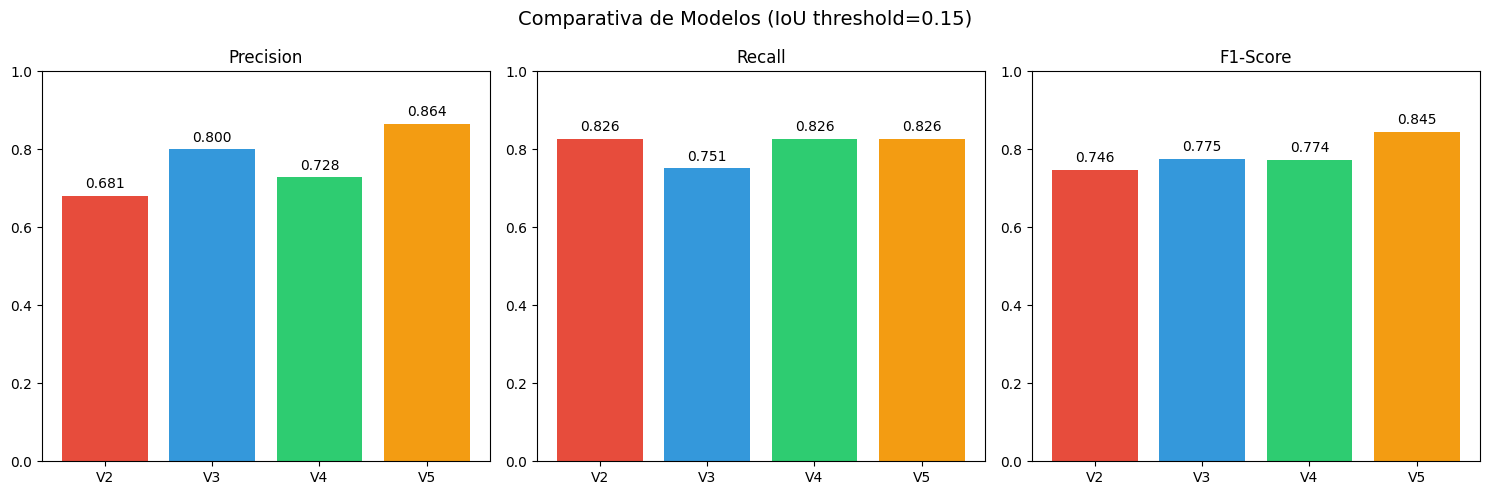

In [5]:
import matplotlib.pyplot as plt
import numpy as np

if all_results:
    df = pd.DataFrame(all_results)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    models = df['Modelo'].values
    x = np.arange(len(models))
    
    # Precision
    axes[0].bar(x, df['Precision'].values, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][:len(models)])
    axes[0].set_title('Precision')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models)
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(df['Precision'].values):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
    
    # Recall
    axes[1].bar(x, df['Recall'].values, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][:len(models)])
    axes[1].set_title('Recall')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models)
    axes[1].set_ylim(0, 1)
    for i, v in enumerate(df['Recall'].values):
        axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
    
    # F1
    axes[2].bar(x, df['F1'].values, color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][:len(models)])
    axes[2].set_title('F1-Score')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(models)
    axes[2].set_ylim(0, 1)
    for i, v in enumerate(df['F1'].values):
        axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)
    
    plt.suptitle(f'Comparativa de Modelos (IoU threshold={IOU_THRESHOLD})', fontsize=14)
    plt.tight_layout()
    
    # Guardar figura
    fig_path = r"D:\Silos\comparativa_modelos.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f"Figura guardada en: {fig_path}")
    plt.show()
else:
    print("No hay resultados para graficar.")

In [6]:
# Exportar predicciones PER-IMAGE: <base>_pred_<MODELO>.shp  (con dedup)
from pathlib import Path
from shapely.geometry import Polygon

PRED_DIR = Path(r"D:\Silos\Pred_Test_Compare")
PRED_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cpu")
test_imgs = [f for f in os.listdir(TEST_DIR) if f.endswith(".tif")]
print(f"Imágenes de test: {len(test_imgs)}\n")

# Cargar los modelos una sola vez
loaded = {}
for model_name, model_path in MODELS.items():
    if not os.path.exists(model_path):
        print(f"[skip] {model_name}: no existe {model_path}")
        continue
    m = get_model_architecture().to(device)
    sd = torch.load(model_path, map_location=device)
    if isinstance(sd, dict) and 'model' in sd and 'optimizer' in sd:
        sd = sd['model']
    m.load_state_dict(sd)
    m.eval()
    loaded[model_name] = m
print(f"Modelos cargados: {list(loaded.keys())}\n")

dir_files = os.listdir(TEST_DIR)

for img_name in test_imgs:
    base = os.path.splitext(img_name)[0]
    img_path = os.path.join(TEST_DIR, img_name)
    with rasterio.open(img_path) as src:
        transform = src.transform
        crs = src.crs

    # GT limpio -> <base>_gt.shp
    gt_shp = next((f for f in dir_files if f.startswith("gt_" + base) and f.endswith(".shp")), None)
    if gt_shp is not None:
        g = gpd.read_file(os.path.join(TEST_DIR, gt_shp))[["geometry"]].copy()
        if len(g) > 0:
            g.to_file(PRED_DIR / f"{base}_gt.shp")

    # Predicción (deduplicada) de cada modelo -> <base>_pred_<MODELO>.shp
    img_tensor = preprocess_image(img_path)
    for model_name, model in loaded.items():
        with torch.no_grad():
            pred = model([img_tensor.to(device)])
        b = pred[0]["boxes"].cpu()
        s = pred[0]["scores"].cpu()
        m = s >= THRESHOLD
        b, s = b[m], s[m]
        if len(b) > 0:
            keep = tv_nms(b, s, NMS_IOU)
            b, s = b[keep], s[keep]
        boxes = b.numpy()
        scores = s.numpy()

        records = []
        for bb, ss in zip(boxes, scores):
            x1, y1, x2, y2 = bb
            corners_px = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
            corners_geo = [rasterio.transform.xy(transform, int(round(yp)), int(round(xp)))
                           for xp, yp in corners_px]
            records.append({"score": float(ss), "geometry": Polygon(corners_geo)})

        if records:
            gdf = gpd.GeoDataFrame(records, geometry="geometry", crs=crs)
            gdf.to_file(PRED_DIR / f"{base}_pred_{model_name}.shp")

    print(f"OK: {base}")

print(f"\nListo. Shapefiles en: {PRED_DIR}")

Imágenes de test: 27

Modelos cargados: ['V2', 'V3', 'V4', 'V5']

OK: 2020_6_10_0_tile_r14_c08
OK: 2020_6_18_2_tile_r25_c01
OK: 2020_6_25_0_tile_r13_c10
OK: 2020_6_25_0_tile_r22_c04
OK: 2020_6_28_1_tile_r11_c09
OK: 2020_6_30_0_tile_r05_c05
OK: 2020_6_5_0_tile_r18_c05
OK: 2020_6_5_0_tile_r22_c02
OK: 2020_6_8_0_tile_r03_c08
OK: 2020_6_8_0_tile_r16_c07
OK: 2020_7_13_0_tile_r12_c08
OK: 2020_7_13_0_tile_r22_c04
OK: 2020_7_13_1_tile_r08_c03
OK: 2020_7_13_1_tile_r11_c05
OK: 2020_7_25_1_tile_r00_c06
OK: 2020_7_28_0_tile_r06_c09
OK: 2020_7_28_1_tile_r19_c06
OK: 2020_7_28_1_tile_r20_c03
OK: 2020_7_30_0_tile_r24_c03
OK: 2020_7_30_1_tile_r17_c07
OK: 2020_7_30_1_tile_r18_c01
OK: 2020_7_8_1_tile_r05_c06
OK: 2020_8_12_0_tile_r23_c03
OK: 2020_8_12_1_tile_r05_c04
OK: 2020_8_12_1_tile_r09_c06
OK: 2020_8_12_1_tile_r11_c06
OK: 2020_8_17_0_tile_r17_c01

Listo. Shapefiles en: D:\Silos\Pred_Test_Compare


In [7]:
# === Significancia estadística: Wilcoxon sobre FP + bootstrap pareado de AP ===
import numpy as np
from scipy.stats import wilcoxon

ag = ['V2', 'V4', 'V5']   # asume 'loaded' ya cargado (como en las celdas previas)
test_imgs = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.tif')])

per_img = {m: [] for m in ag}
for img_name in test_imgs:
    gt = get_gt_boxes(img_name, TEST_DIR)
    img_t = preprocess_image(os.path.join(TEST_DIR, img_name))
    for m in ag:
        b, s = dedup_boxes(loaded[m], img_t)              # >=0.5 + NMS -> punto de operación
        fp = len(b) - len(matched_idx(b, s, gt))
        bb, ss = nms_all(loaded[m], img_t); ss = ss.numpy()  # sin umbral -> para AP
        dets, mm = [], set()
        iou = box_iou(bb, gt) if (len(bb) > 0 and len(gt) > 0) else None
        for pi in np.argsort(-ss):
            is_tp = 0
            if iou is not None:
                best, bg = 0, -1
                for gj in range(len(gt)):
                    if gj in mm: continue
                    v = iou[pi, gj].item()
                    if v > best: best, bg = v, gj
                if best >= IOU_THRESHOLD and bg >= 0: mm.add(bg); is_tp = 1
            dets.append((float(ss[pi]), is_tp))
        per_img[m].append(dict(fp=fp, dets=dets, n_gt=len(gt)))

# (1) Wilcoxon pareado sobre FP por imagen
for a, b in [('V5','V4'), ('V5','V2'), ('V4','V2')]:
    diff = np.array([per_img[a][i]['fp'] - per_img[b][i]['fp'] for i in range(len(test_imgs))])
    p = wilcoxon(diff).pvalue if np.any(diff) else 1.0
    print(f"FP {a} vs {b}: mediana dif = {np.median(diff):+.1f} | Wilcoxon p = {p:.4f}")

# (2) Bootstrap pareado sobre imágenes para diferencia de AP (curva completa)
def ap(imgs):
    dets = [d for im in imgs for d in im['dets']]; n_gt = sum(im['n_gt'] for im in imgs)
    if n_gt == 0 or not dets: return np.nan
    dets.sort(key=lambda x: -x[0]); tp = np.array([d[1] for d in dets])
    ctp, cfp = np.cumsum(tp), np.cumsum(1 - tp)
    prec, rec = ctp / np.maximum(ctp + cfp, 1), ctp / n_gt
    return sum((prec[rec >= t].max() if (rec >= t).any() else 0) for t in np.arange(0, 1.1, 0.1)) / 11

rng, N, B = np.random.default_rng(0), len(test_imgs), 2000
for a, b in [('V4','V2'), ('V5','V4'), ('V5','V2')]:
    d = np.array([ap([per_img[a][i] for i in idx]) - ap([per_img[b][i] for i in idx])
                  for idx in (rng.integers(0, N, N) for _ in range(B))])
    lo, hi = np.percentile(d, [2.5, 97.5]); pb = 2 * min((d <= 0).mean(), (d >= 0).mean())
    print(f"AP {a}-{b}: dif = {d.mean():+.3f} | IC95% = [{lo:+.3f}, {hi:+.3f}] | p≈{pb:.3f}")

FP V5 vs V4: mediana dif = -2.0 | Wilcoxon p = 0.0005
FP V5 vs V2: mediana dif = -4.0 | Wilcoxon p = 0.0001
FP V4 vs V2: mediana dif = -1.0 | Wilcoxon p = 0.0558
AP V4-V2: dif = +0.022 | IC95% = [-0.014, +0.059] | p≈0.410
AP V5-V4: dif = +0.038 | IC95% = [+0.008, +0.083] | p≈0.027
AP V5-V2: dif = +0.060 | IC95% = [+0.014, +0.092] | p≈0.002
